Image Recommendation System Using Autoencoder

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# Configuration
train_directory = "data/Train"
test_directory = "data/Test"
batch_size = 64
image_size = (32, 32)
epochs = 25
model_path = "model/encoder_model.keras"

In [3]:
def create_data_generator(base_directory, batch_size, image_size):
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    generator = datagen.flow_from_directory(
        base_directory,
        target_size=image_size,
        batch_size=batch_size,
        class_mode=None,
        shuffle=True,
        color_mode='rgb'
    )
    return generator

def create_autoencoder_generator(image_generator):
    for batch in image_generator:
        yield (batch, batch)

train_generator = create_data_generator("data", batch_size, image_size)
test_generator = create_data_generator("data", batch_size, image_size)

Found 44364 images belonging to 2 classes.
Found 44364 images belonging to 2 classes.


In [4]:
def build_autoencoder(input_shape):
    encoder = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu')  # Latent space
    ])

    decoder = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(32,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(input_shape[0] * input_shape[1] * input_shape[2], activation='sigmoid'),
        layers.Reshape(input_shape)
    ])

    autoencoder = models.Sequential([encoder, decoder])
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder

input_shape = image_size + (3,)  # RGB
autoencoder = build_autoencoder(input_shape)

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
autoencoder_train_generator = create_autoencoder_generator(train_generator)
autoencoder_test_generator = create_autoencoder_generator(test_generator)

history = autoencoder.fit(
    autoencoder_train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=autoencoder_test_generator,
    validation_steps=len(test_generator),
    epochs=epochs
)

# Save the model
autoencoder.save(model_path)

In [8]:
import os

model_path = "model/encoder_model.keras"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

print("Directory contents:", os.listdir("model"))  # This will show the contents inside 'model' folder (empty if newly created)


Directory contents: []


In [9]:
import os

model_path = "model/encoder_model.keras"

autoencoder_train_generator = create_autoencoder_generator(train_generator)
autoencoder_test_generator = create_autoencoder_generator(test_generator)

history = autoencoder.fit(
    autoencoder_train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=autoencoder_test_generator,
    validation_steps=len(test_generator),
    epochs=epochs
)

os.makedirs(os.path.dirname(model_path), exist_ok=True)
autoencoder.save(model_path)
print("Autoencoder trained and saved at:", model_path)


Epoch 1/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1403s 2s/step - loss: 0.2030 - val_loss: 0.1989
Epoch 2/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1379s 2s/step - loss: 0.1996 - val_loss: 0.1985
Epoch 3/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1368s 2s/step - loss: 0.1986 - val_loss: 0.1983
Epoch 4/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1370s 2s/step - loss: 0.1987 - val_loss: 0.1983
Epoch 5/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1372s 2s/step - loss: 0.1992 - val_loss: 0.1983
Epoch 6/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1360s 2s/step - loss: 0.1986 - val_loss: 0.1979
Epoch 7/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1338s 2s/step - loss: 0.1988 - val_loss: 0.1980
Epoch 8/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1293s 2s/step - loss: 0.1980 - val_loss: 0.1977
Epoch 9/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 1195s 2s/step - loss: 0.1974 - val_loss: 0.1976
Epoch 10/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 950s 1s/step - loss: 0.1979 - val_loss: 0.1976
Epoch 11/25
694/694 ━━━━━━━━━━━━━━━━━━━━ 790s 1s/step - loss: 0.1975 - val_loss: 0.1972
Epoch 12/25
694/694 ━━━━━━━━━━━━

In [11]:
pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 5.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


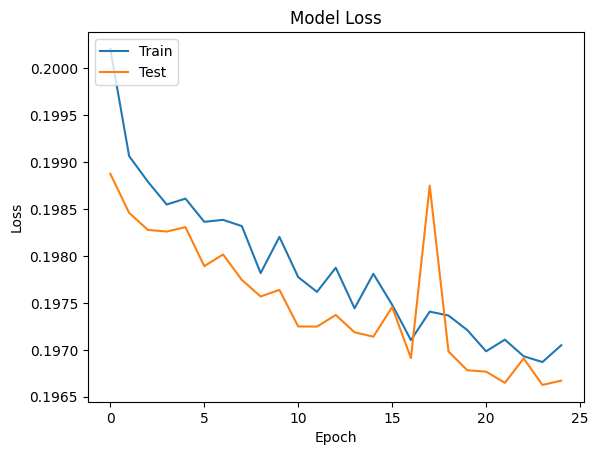

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()